# Анализ набора данных Cars Moldova: предсказание цены автомобиля (регрессия)

**Задача:** предсказать цену подержанного автомобиля (`Price(euro)`) по его характеристикам. Целевая переменная непрерывная, поэтому это **задача регрессии**.

**План работы**
1. Импорт библиотек и загрузка данных
2. Первичный осмотр и очистка данных
3. Визуализация (5 графиков, не повторяющих демонстрационные блокноты)
4. «Скучная» статистика: `describe`, `groupby`, `agg`, корреляции
5. Предварительная обработка: `Pipeline` + `ColumnTransformer`, сохранение результата
6. Итоги

## 1. Импорт библиотек и загрузка данных

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, PowerTransformer, StandardScaler

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="talk")   # крупный шрифт, чтобы графики читались
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

In [2]:
# Если запускаете в Google Colab: загрузите cars_moldova.csv через панель «Файлы» слева
df_raw = pd.read_csv("cars_moldova.csv")
print("Размер набора данных:", df_raw.shape)
df_raw.head()

Размер набора данных: (41007, 9)


## 2. Первичный осмотр и очистка данных

### 2.1 Общая информация
Смотрим типы признаков, пропуски и дубликаты.

In [3]:
df_raw.info()
print("\nПропусков всего:", int(df_raw.isna().sum().sum()))
print("Полных дубликатов строк:", int(df_raw.duplicated().sum()))

<class 'pandas.DataFrame'>
RangeIndex: 41007 entries, 0 to 41006
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Make                  41007 non-null  str    
 1   Model                 41007 non-null  str    
 2   Year                  41007 non-null  int64  
 3   Style                 41007 non-null  str    
 4   Distance              41007 non-null  float64
 5   Engine_capacity(cm3)  41007 non-null  float64
 6   Fuel_type             41007 non-null  str    
 7   Transmission          41007 non-null  str    
 8   Price(euro)           41007 non-null  float64
dtypes: float64(3), int64(1), str(5)
memory usage: 2.8 MB

Пропусков всего: 0
Полных дубликатов строк: 3743


In [4]:
display(df_raw.describe(percentiles=[0.01, 0.5, 0.99]).T)

,count,mean,std,min,1%,50%,99%,max
Year,41007.0,2007.976175,8.241487e+00,1900.0,1986.0,2009.0,2020.00,2021.0
Distance,41007.0,456735.302387,4.451897e+06,0.0,0.0,168000.0,1959873.76,100000000.0
Engine_capacity(cm3),41007.0,1853.856732,7.003645e+02,0.0,100.0,1800.0,4400.00,9999.0
Price(euro),41007.0,9727.109079,5.043926e+04,1.0,600.0,6600.0,49900.00,10000000.0


**Что видно.** Пропусков нет, но есть три проблемы:
* **Дубликаты** (около 9% строк) — одно и то же объявление, выгруженное несколько раз.
* **Выбросы и ошибки ввода:** максимальная цена 10 000 000 €, максимальный пробег 100 000 000 км, год выпуска от 1900, объём двигателя от 0 до 9999 см³.
* **Пробег в разных единицах:** у многих старых машин пробег записан как 22 или 150, то есть, вероятно, в тысячах км.

Ниже исправляем это явно, шаг за шагом, и считаем, сколько строк затронуто каждым правилом.

### 2.2 Очистка

In [5]:
df = df_raw.drop_duplicates().copy()
print(f"После удаления дубликатов: {len(df)} строк")

# 1) Пробег 1..999 км у машин не из последних лет выпуска — скорее всего, указан в тысячах км
in_thousands = df["Distance"].between(1, 999) & (df["Year"] < 2018)
print("Пробег домножен на 1000 у строк:", int(in_thousands.sum()))
df.loc[in_thousands, "Distance"] *= 1000

# 2) Правила отсечения нереалистичных значений
rules = {
    "Year >= 1980":                       df["Year"] >= 1980,
    "300 <= Price <= 100000":             df["Price(euro)"].between(300, 100_000),
    "1000 <= Distance <= 600000":         df["Distance"].between(1_000, 600_000),
    # двигатель 0 см³ допустим только у электромобилей
    "Engine 600..7000 (или 0 у Electric)": df["Engine_capacity(cm3)"].between(600, 7000)
                                           | ((df["Fuel_type"] == "Electric") & (df["Engine_capacity(cm3)"] < 7000)),
}
mask = pd.Series(True, index=df.index)
for name, rule in rules.items():
    print(f"{name:40s} нарушают {int((~rule).sum()):5d} строк")
    mask &= rule

df = df[mask].reset_index(drop=True)
print(f"\nИтого после очистки: {len(df)} строк ({len(df)/len(df_raw):.1%} от исходных)")

После удаления дубликатов: 37264 строк
Пробег домножен на 1000 у строк: 2645
Year >= 1980                             нарушают   141 строк
300 <= Price <= 100000                   нарушают    59 строк
1000 <= Distance <= 600000               нарушают  1554 строк
Engine 600..7000 (или 0 у Electric)      нарушают   963 строк

Итого после очистки: 34666 строк (84.5% от исходных)


In [6]:
# Упростим названия столбцов, чтобы удобнее работать
df = df.rename(columns={"Price(euro)": "Price", "Engine_capacity(cm3)": "Engine"})
df["Age"] = 2021 - df["Year"]          # возраст машины (данные собраны около 2021 года)
df["LogPrice"] = np.log1p(df["Price"])  # понадобится для графиков и модели
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Year,34666.0,2008.127416,7.198751,1980.00000,2004.000000,2009.000000,2014.00000,2021.000000
Distance,34666.0,175272.390296,97663.788057,1000.00000,112076.500000,177000.000000,234000.00000,600000.000000
Engine,34666.0,1897.395056,635.518460,0.00000,1500.000000,1800.000000,2000.00000,6800.000000
Price,34666.0,9295.947412,9495.261468,300.00000,3500.000000,6500.000000,11950.00000,100000.000000
Age,34666.0,12.872584,7.198751,0.00000,7.000000,12.000000,17.00000,41.000000
LogPrice,34666.0,8.744065,0.913052,5.70711,8.160804,8.779711,9.38857,11.512935


**Вывод.** Диапазоны стали реалистичными: цена от 300 до 100 000 €, пробег до 600 тыс. км, возраст до 41 года. Дальше работаем с очищенным `df`.

## 3. Визуализация данных

В демонстрационных блокнотах уже использовались `histplot`, `pairplot`, `scatterplot`, `catplot`, `relplot`, `displot`. Здесь применены другие графики: `hist` из pandas, `jointplot` (hexbin), `violinplot`, `lmplot`, `boxenplot`, пузырьковая диаграмма (matplotlib) и `heatmap`.

### 3.1 Распределение целевой переменной: цена и логарифм цены
Нужно решить, можно ли работать с ценой «как есть» или её надо преобразовать.

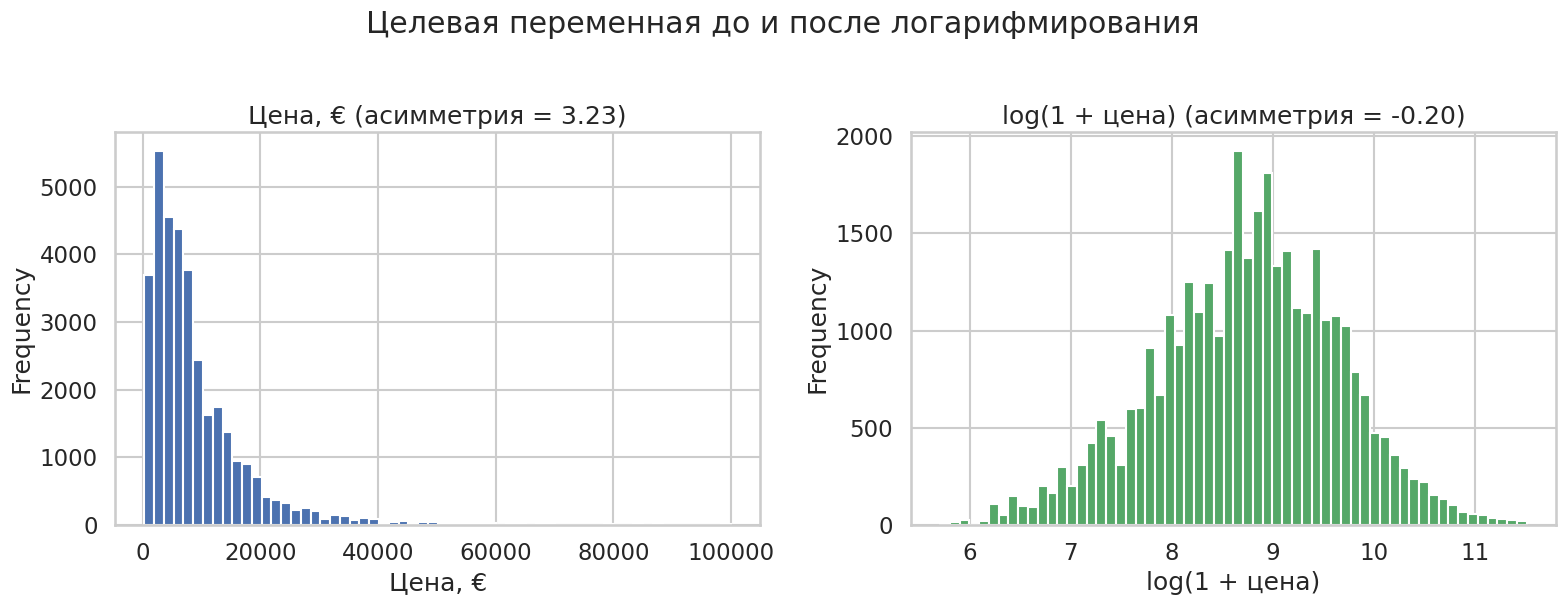

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["Price"].plot.hist(bins=60, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title(f"Цена, € (асимметрия = {df['Price'].skew():.2f})")
axes[0].set_xlabel("Цена, €")
df["LogPrice"].plot.hist(bins=60, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title(f"log(1 + цена) (асимметрия = {df['LogPrice'].skew():.2f})")
axes[1].set_xlabel("log(1 + цена)")
fig.suptitle("Целевая переменная до и после логарифмирования", y=1.02)
plt.tight_layout(); plt.show()

**Что мы видим.** Цена сильно скошена вправо: большинство машин стоит до 10 000 €, но есть длинный «хвост» дорогих. После логарифмирования распределение почти симметрично и ближе к нормальному. Для линейных моделей лучше предсказывать `log(1 + цена)`, поэтому целевую переменную мы будем логарифмировать.

### 3.2 Пробег и цена: hexbin-график (`jointplot`)
Точек больше 30 тысяч, обычный scatter превратится в «кляксу». Hexbin показывает плотность. По оси Y стоит целевая переменная.

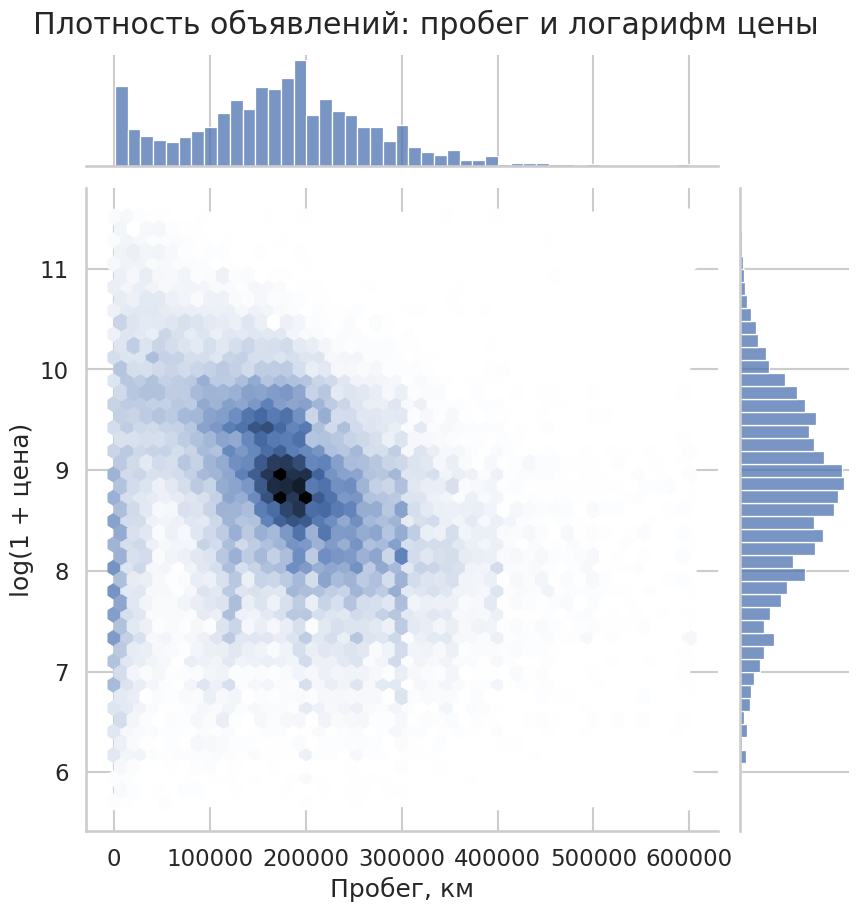

In [8]:
g = sns.jointplot(data=df, x="Distance", y="LogPrice", kind="hex", height=9,
                  color="#4C72B0", gridsize=45, marginal_kws=dict(bins=45))
g.set_axis_labels("Пробег, км", "log(1 + цена)")
g.figure.suptitle("Плотность объявлений: пробег и логарифм цены", y=1.02)
plt.show()

**Что мы видим.** Основная масса объявлений приходится на пробег 100–300 тыс. км (тёмное ядро, пик около 170–200 тыс. км и цены порядка e^9 ≈ 8 000 €). Облако слегка наклонено вниз-вправо: чем больше пробег, тем ниже цена, но связь слабая, а разброс цен при одном и том же пробеге очень большой (от 6 до 11 по оси Y). На гистограмме сверху виден отдельный всплеск у малых пробегов: это почти новые машины. Значит, пробег сам по себе цену объясняет плохо и должен использоваться вместе с возрастом и другими признаками.

### 3.3 Цена по типу топлива и коробке передач: `violinplot` со split
Один график объединяет сразу три признака: топливо, коробку передач и цену.

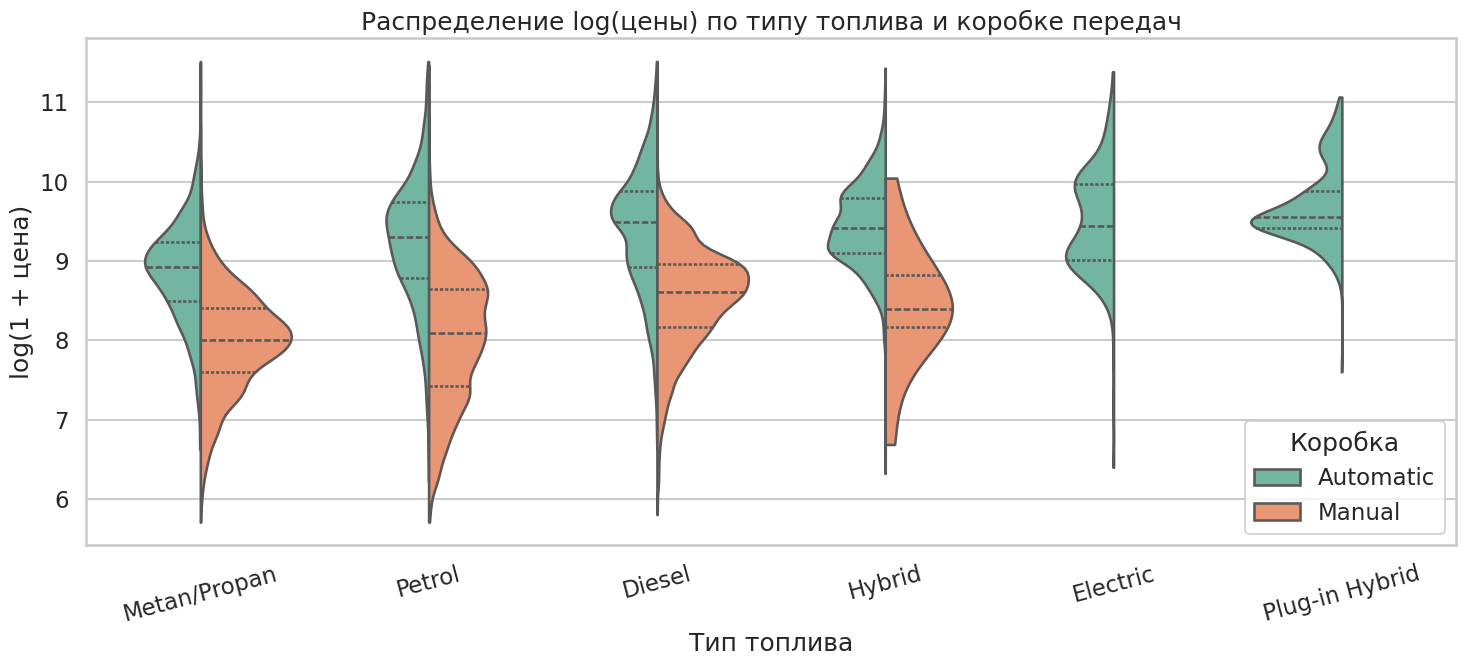

In [9]:
order = df.groupby("Fuel_type")["LogPrice"].median().sort_values().index
plt.figure(figsize=(15, 7))
sns.violinplot(data=df, x="Fuel_type", y="LogPrice", hue="Transmission", order=order,
               split=True, inner="quart", palette="Set2", cut=0)
plt.title("Распределение log(цены) по типу топлива и коробке передач")
plt.xlabel("Тип топлива"); plt.ylabel("log(1 + цена)")
plt.xticks(rotation=15); plt.legend(title="Коробка")
plt.tight_layout(); plt.show()

**Что мы видим.** Виды топлива упорядочены по медианной цене: метан/пропан самый дешёвый, затем бензин и дизель, а гибриды, электромобили и Plug-in гибриды заметно дороже. Для метана, бензина, дизеля и гибридов автомат (левая половина «скрипки») смещён к более высоким ценам, чем механика, причём разница порядка 1–2 единиц в логарифмической шкале. У электромобилей и Plug-in гибридов механики практически нет, поэтому у них только одна половина. Значит, и `Fuel_type`, и `Transmission` полезны для модели.

### 3.4 Возраст и цена с разбивкой по топливу: `lmplot`
Показываем, как падает цена с возрастом, и отличается ли скорость падения у разных типов топлива. Для читаемости берём случайную выборку.

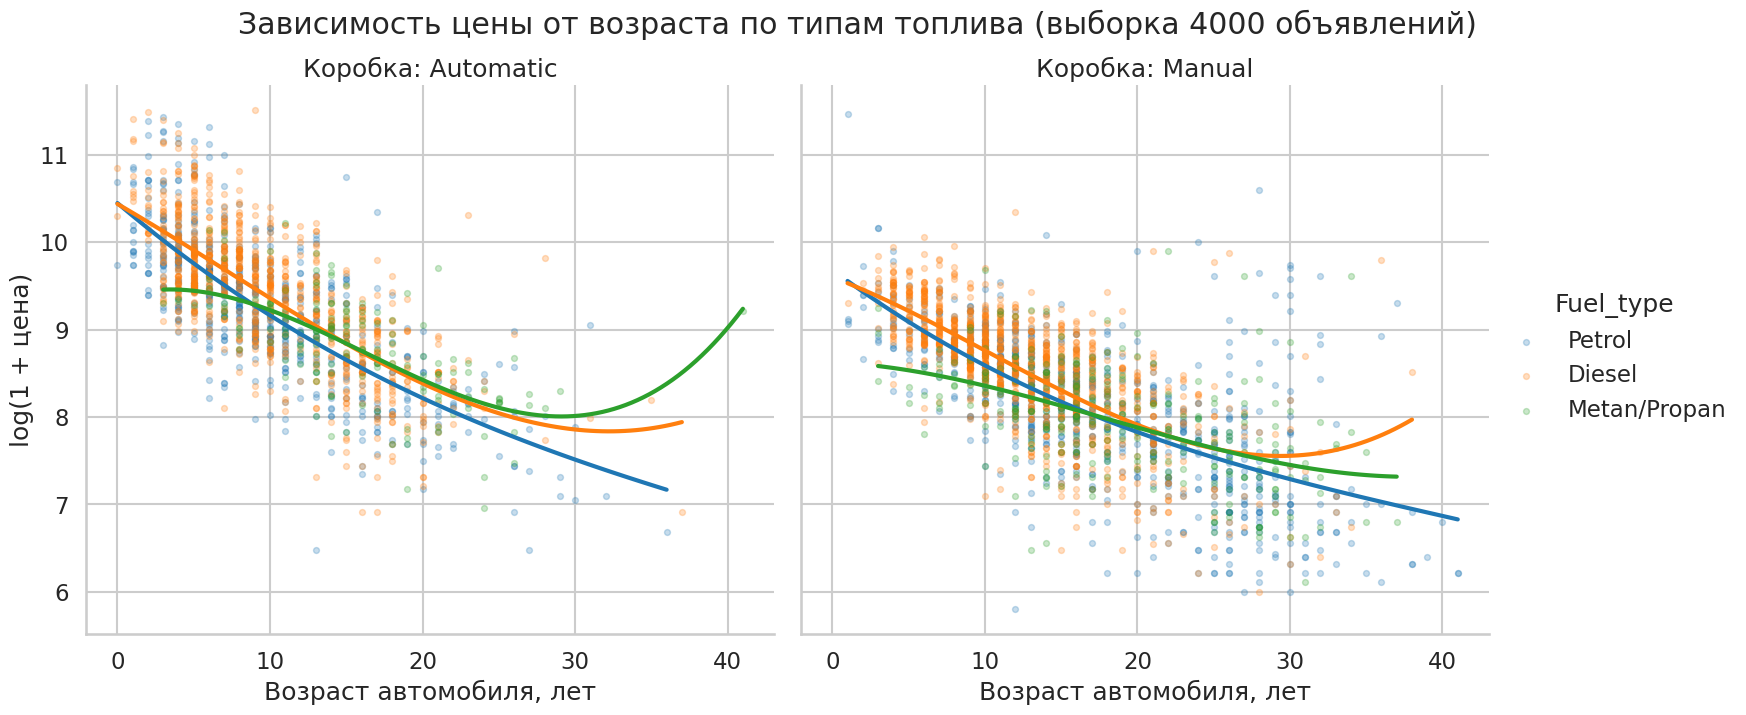

In [10]:
top_fuels = ["Diesel", "Petrol", "Metan/Propan"]   # гибридов с механикой почти нет (16 шт.), линию по ним не построить
sample = df[df["Fuel_type"].isin(top_fuels)].sample(4000, random_state=RANDOM_STATE)
g = sns.lmplot(data=sample, x="Age", y="LogPrice", hue="Fuel_type", col="Transmission",
               height=7, aspect=1.1, scatter_kws=dict(alpha=0.25, s=18), line_kws=dict(linewidth=3),
               palette="tab10", order=3, ci=None)
g.set_axis_labels("Возраст автомобиля, лет", "log(1 + цена)")
g.set_titles("Коробка: {col_name}")
g.figure.suptitle("Зависимость цены от возраста по типам топлива (выборка 4000 объявлений)", y=1.03)
plt.show()

**Что мы видим.** Для всех типов топлива цена убывает с возрастом, причём зависимость нелинейная (поэтому подогнан полином 3-й степени, а не прямая). У автоматов (левая панель) кривые начинаются выше (около 10 в логарифмической шкале против 9–9,5 у механики) и падают круче. На старых машинах (старше 25–30 лет) точек мало, и «загибы» кривых справа не стоит воспринимать всерьёз. Вывод: возраст — один из самых сильных предикторов цены, а его эффект различается для разных коробок, то есть признаки взаимодействуют.

### 3.5 Цена по кузову: `boxenplot`
`boxenplot` показывает не только квартили, но и «хвосты», что удобно для скошенных данных.

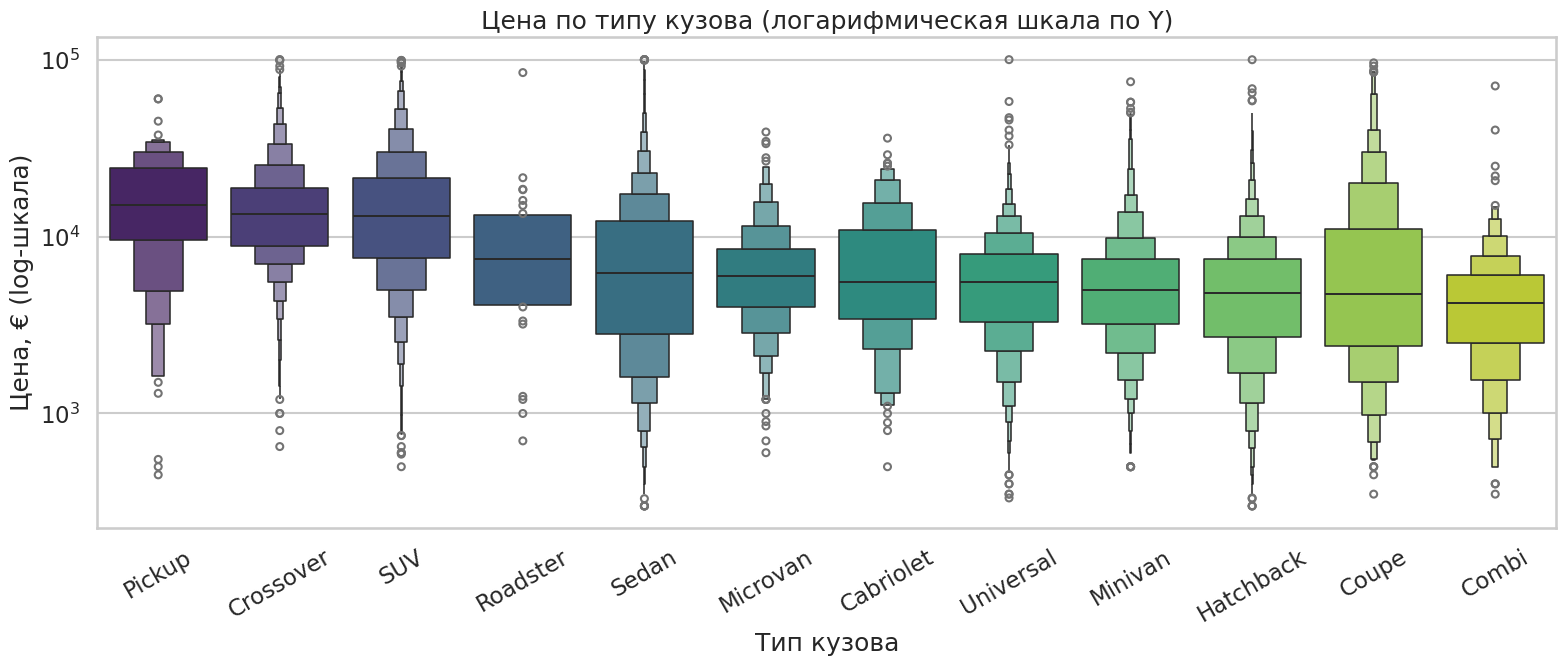

In [11]:
order = df.groupby("Style")["Price"].median().sort_values(ascending=False).index
plt.figure(figsize=(16, 7))
sns.boxenplot(data=df, x="Style", y="Price", order=order, palette="viridis")
plt.yscale("log")
plt.title("Цена по типу кузова (логарифмическая шкала по Y)")
plt.xlabel("Тип кузова"); plt.ylabel("Цена, € (log-шкала)")
plt.xticks(rotation=30)
plt.tight_layout(); plt.show()

**Что мы видим.** Типы кузова заметно различаются по медианной цене: пикапы, кроссоверы и SUV дороже, чем универсалы и седаны. Распределения внутри каждого кузова широкие и сильно перекрываются, так что кузов — полезный, но не решающий признак.

### 3.6 Пузырьковая диаграмма по маркам: 4 признака на одном графике
Агрегируем данные по маркам и показываем сразу несколько признаков в двумерном графике: по X — средний возраст, по Y — медианная цена, размер пузыря — число объявлений, цвет — средний объём двигателя.

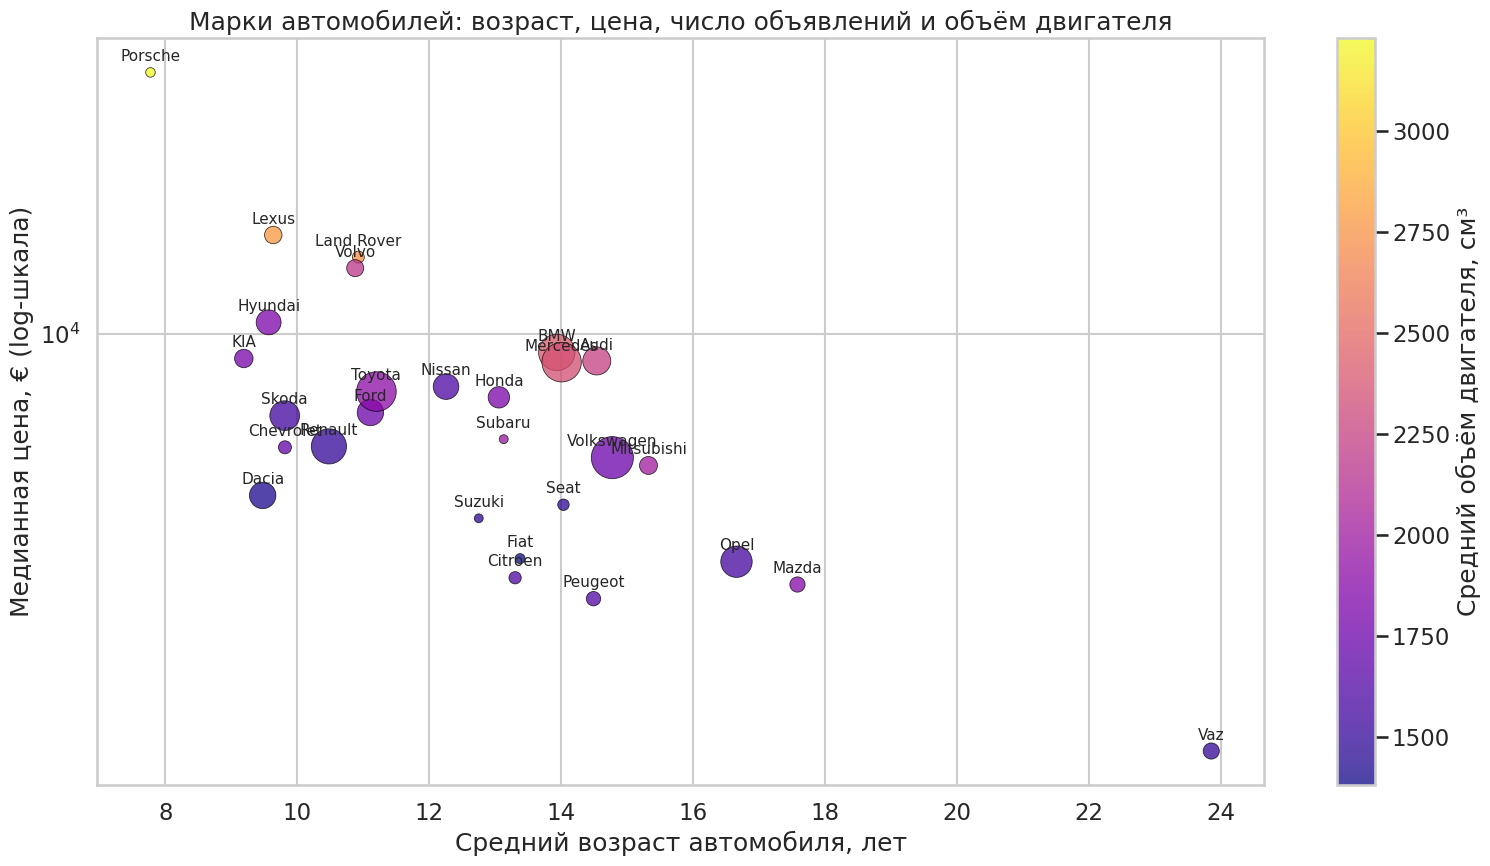

In [12]:
make_stats = (df.groupby("Make")
                .agg(count=("Price", "size"), median_price=("Price", "median"),
                     mean_age=("Age", "mean"), mean_engine=("Engine", "mean"))
                .query("count >= 150"))

fig, ax = plt.subplots(figsize=(16, 9))
sc = ax.scatter(make_stats["mean_age"], make_stats["median_price"],
                s=make_stats["count"] / 4, c=make_stats["mean_engine"],
                cmap="plasma", alpha=0.75, edgecolor="black", linewidth=0.6)
for make, row in make_stats.iterrows():
    ax.annotate(make, (row["mean_age"], row["median_price"]), fontsize=11, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")
ax.set_yscale("log")
ax.set_xlabel("Средний возраст автомобиля, лет")
ax.set_ylabel("Медианная цена, € (log-шкала)")
ax.set_title("Марки автомобилей: возраст, цена, число объявлений и объём двигателя")
fig.colorbar(sc, label="Средний объём двигателя, см³")
plt.tight_layout(); plt.show()

**Что мы видим.** В целом чем моложе парк марки (левая часть), тем выше медианная цена: Porsche — самая «молодая» и самая дорогая марка (с самым большим двигателем), за ней идут Lexus, Land Rover и Volvo. ВАЗ (Vaz) — самая старая и самая дешёвая. Mercedes, BMW и Audi (крупные розовые пузыри) имеют средний возраст около 14 лет, но держат цену около 9 тыс. € благодаря крупным двигателям. Размер пузыря показывает массовость: Volkswagen, Mercedes, Toyota и BMW — самые крупные. Вывод: `Make` несёт много информации о цене, но марок около 80, а часть из них редкие, поэтому кодировать её нужно аккуратно.

## 4. «Скучная» статистика

### 4.1 Числовые признаки: `describe` и асимметрия

In [13]:
num_cols = ["Year", "Distance", "Engine", "Price"]
stats = df[num_cols].describe().T
stats["skew"] = df[num_cols].skew()
display(stats.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
Year,34666.0,2008.13,7.20,1980.0,2004.0,2009.0,2014.0,2021.0,-0.83
Distance,34666.0,175272.39,97663.79,1000.0,112076.5,177000.0,234000.0,600000.0,0.35
Engine,34666.0,1897.40,635.52,0.0,1500.0,1800.0,2000.0,6800.0,1.78
Price,34666.0,9295.95,9495.26,300.0,3500.0,6500.0,11950.0,100000.0,3.23


**Что показывает статистика.** Медианная цена (6,5 тыс. €) заметно ниже средней (9,3 тыс. €), асимметрия цены сильно положительная (3,2), что подтверждает гистограмму. Объём двигателя тоже скошен вправо (1,8), а пробег почти симметричен (0,35). Год выпуска скошен влево: много относительно свежих машин.

### 4.2 Корреляция числовых признаков с целевой переменной
Считаем и Пирсона (линейная связь), и Спирмена (монотонная связь). Если они сильно различаются, связь нелинейная.

,Pearson с Price,Spearman с Price,Pearson с LogPrice,Spearman с LogPrice
Age,-0.548,-0.775,-0.751,-0.775
Distance,-0.295,-0.280,-0.244,-0.280
Engine,0.364,0.310,0.300,0.310


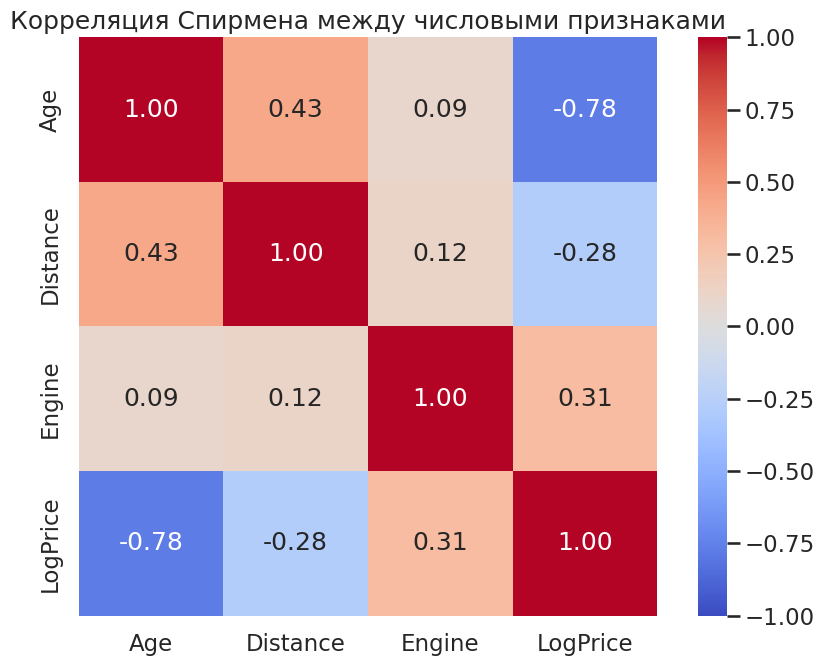

In [14]:
corr_cols = ["Age", "Distance", "Engine"]
corr_table = pd.DataFrame({
    "Pearson с Price":     df[corr_cols].corrwith(df["Price"]),
    "Spearman с Price":    df[corr_cols].corrwith(df["Price"], method="spearman"),
    "Pearson с LogPrice":  df[corr_cols].corrwith(df["LogPrice"]),
    "Spearman с LogPrice": df[corr_cols].corrwith(df["LogPrice"], method="spearman"),
})
display(corr_table.round(3))

plt.figure(figsize=(9, 7))
sns.heatmap(df[["Age", "Distance", "Engine", "LogPrice"]].corr(method="spearman"),
            annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Корреляция Спирмена между числовыми признаками")
plt.tight_layout(); plt.show()

**Что показывает статистика.** Самая сильная связь с ценой — у возраста (отрицательная): чем старше машина, тем она дешевле. Пробег тоже связан с ценой отрицательно, но слабее, и он умеренно коррелирует с возрастом (около 0,43), так что часть информации дублируется. Объём двигателя связан с ценой положительно и тоже слабее возраста. Для возраста корреляция Спирмена (около −0,78) по модулю заметно больше Пирсона (около −0,55): связь монотонная, но нелинейная. Это ещё один довод в пользу логарифма цены.

### 4.3 Категориальные признаки: группировка и агрегаты по цене
Для каждого категориального признака считаем статистики целевой переменной по группам.

In [15]:
agg_funcs = ["count", "mean", "median", "std", "min", "max"]

for col in ["Fuel_type", "Transmission", "Style"]:
    print(f"=== Цена по признаку {col} ===")
    display(df.groupby(col)["Price"].agg(agg_funcs).sort_values("median", ascending=False).round(0))

=== Цена по признаку Fuel_type ===
=== Цена по признаку Transmission ===
=== Цена по признаку Style ===


,count,mean,median,std,min,max
Fuel_type,,,,,,
Plug-in Hybrid,450,18292.0,14000.0,10405.0,2000.0,63900.0
Electric,251,16356.0,12500.0,11715.0,600.0,87900.0
Hybrid,1913,14353.0,12200.0,8378.0,555.0,92000.0
Diesel,16227,10100.0,7100.0,9747.0,330.0,100000.0
Petrol,11984,8175.0,5450.0,9526.0,300.0,99900.0
Metan/Propan,3841,5364.0,3950.0,5017.0,300.0,100000.0


,count,mean,median,std,min,max
Transmission,,,,,,
Automatic,15619,14431.0,11800.0,11475.0,500.0,100000.0
Manual,19047,5085.0,4300.0,4095.0,300.0,100000.0


,count,mean,median,std,min,max
Style,,,,,,
Pickup,151,16830.0,15000.0,10908.0,450.0,60000.0
Crossover,4197,15895.0,13500.0,10867.0,650.0,100000.0
SUV,3260,16888.0,13000.0,14059.0,500.0,99000.0
Roadster,26,11553.0,7500.0,16041.0,700.0,84500.0
Sedan,10416,9016.0,6200.0,9424.0,300.0,100000.0
Microvan,456,7070.0,5995.0,5088.0,600.0,39000.0
Cabriolet,137,7994.0,5500.0,6689.0,500.0,36000.0
Universal,6362,6271.0,5500.0,4373.0,333.0,100000.0
Minivan,2922,6229.0,5000.0,5513.0,500.0,75000.0


In [16]:
print("=== 15 самых массовых марок ===")
top_makes = df["Make"].value_counts().head(15).index
display(df[df["Make"].isin(top_makes)].groupby("Make")["Price"]
          .agg(agg_funcs).sort_values("median", ascending=False).round(0))

print("Уникальных значений:", df[["Make", "Model", "Style", "Fuel_type", "Transmission"]].nunique().to_dict())

=== 15 самых массовых марок ===
Уникальных значений: {'Make': 80, 'Model': 803, 'Style': 12, 'Fuel_type': 6, 'Transmission': 2}


,count,mean,median,std,min,max
Make,,,,,,
Hyundai,1284,11958.0,10550.0,9279.0,350.0,68299.0
BMW,2747,13598.0,9200.0,13035.0,300.0,100000.0
KIA,707,11335.0,8950.0,9423.0,470.0,100000.0
Audi,1629,12273.0,8850.0,12503.0,400.0,92000.0
Mercedes,3221,12992.0,8800.0,12524.0,650.0,99000.0
Nissan,1358,7905.0,7874.0,4906.0,400.0,58000.0
Toyota,3258,9573.0,7699.0,7044.0,500.0,82999.0
Honda,952,9045.0,7500.0,6801.0,500.0,100000.0
Ford,1446,7935.0,7000.0,5875.0,333.0,60000.0


**Что показывает статистика.**
* **Топливо:** у электромобилей, гибридов и Plug-in гибридов медианная цена (12–14 тыс. €) более чем вдвое выше, чем у бензина (5,5 тыс. €) и газа (4 тыс. €). У электромобилей и Plug-in гибридов мало объявлений (250 и 450), а разброс цен большой.
* **Коробка:** медиана цены у автоматов заметно выше, чем у механики.
* **Кузов:** пикапы, SUV и кроссоверы дороже, а редкие типы (Roadster, Cabriolet) имеют очень мало наблюдений, и среднее по ним ненадёжно.
* **Марка:** среди 15 самых массовых лидируют по медианной цене Hyundai, BMW, KIA, Audi и Mercedes, а самые дешёвые — Opel, Dacia и Volkswagen. Причём у Hyundai и KIA это отчасти следствие более молодого парка.
* У `Make` около 80 значений, а у `Model` — около 800, поэтому One-Hot по `Model` породит слишком много столбцов. Для редких категорий понадобится особая обработка.

## 5. Предварительная обработка данных

Решения принимаем на основе того, что увидели выше:

| Признак | Что наблюдали | Преобразование |
|---|---|---|
| `LogPrice` (цель) | цена сильно скошена, логарифм симметричен | предсказываем `log(1 + Price)` |
| `Year` | связь с ценой нелинейная, удобнее возраст | свой трансформер `AgeTransformer` (возраст) → `StandardScaler` |
| `Distance` | после очистки почти симметричен (skew ≈ 0,35) | достаточно `StandardScaler` |
| `Engine` | сильно скошен вправо (skew ≈ 1,8): редкие машины с мощными моторами | `PowerTransformer` (Yeo-Johnson, т.к. есть нули у электромобилей) |
| `Transmission` | 2 значения, у автомата цена выше | `OrdinalEncoder` (Manual=0, Automatic=1) |
| `Fuel_type`, `Style` | мало значений, часть редких | свой `RareCategoryGrouper` → `OneHotEncoder` |
| `Make` | 87 значений, много редких | `RareCategoryGrouper` → `OneHotEncoder` |
| `Model` | 800+ значений | свой `FrequencyEncoder` (частота модели) |

Сначала проверим, у каких числовых признаков есть смысл применять степенное преобразование.

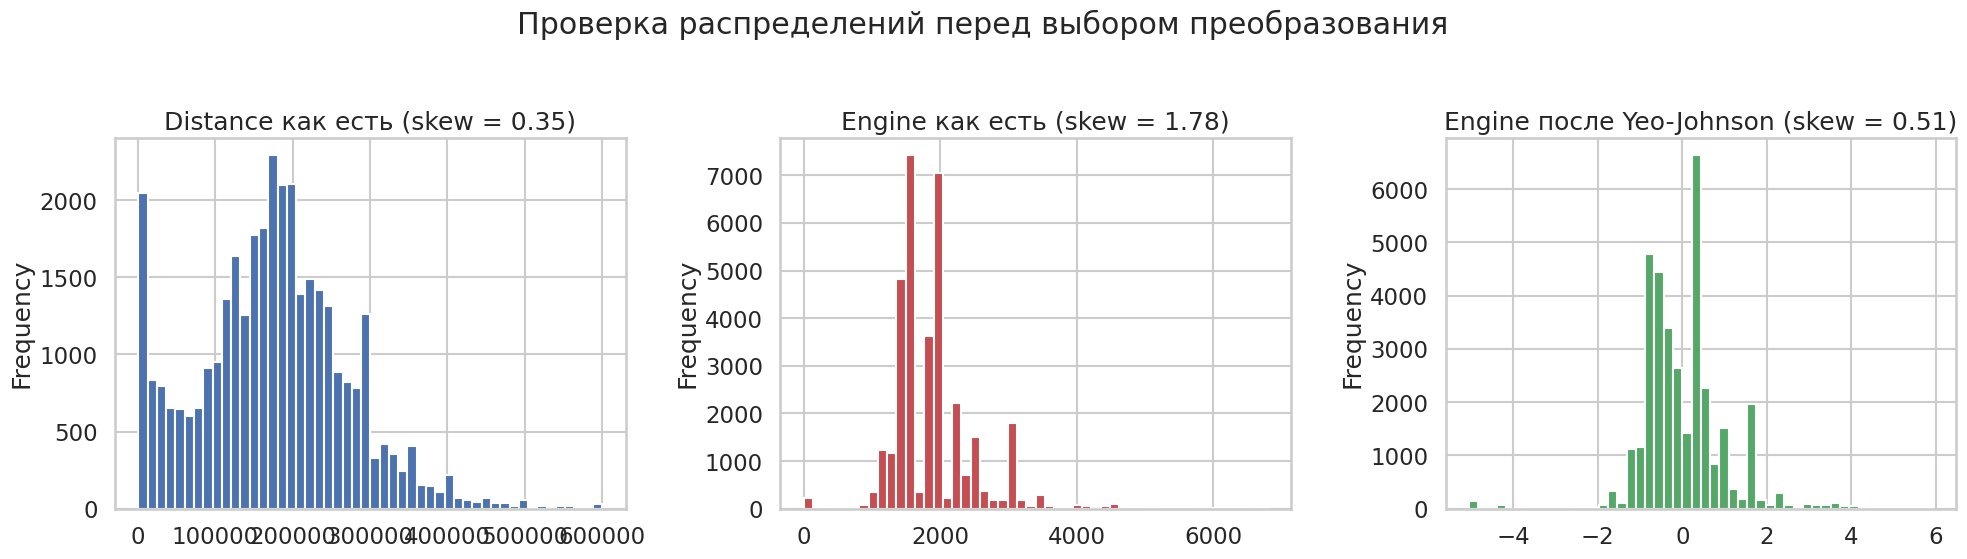

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
df["Distance"].plot.hist(bins=50, ax=axes[0], color="#4C72B0", edgecolor="white")
axes[0].set_title(f"Distance как есть (skew = {df['Distance'].skew():.2f})")

df["Engine"].plot.hist(bins=50, ax=axes[1], color="#C44E52", edgecolor="white")
axes[1].set_title(f"Engine как есть (skew = {df['Engine'].skew():.2f})")

engine_pt = PowerTransformer(method="yeo-johnson").fit_transform(df[["Engine"]]).ravel()
pd.Series(engine_pt).plot.hist(bins=50, ax=axes[2], color="#55A868", edgecolor="white")
axes[2].set_title(f"Engine после Yeo-Johnson (skew = {pd.Series(engine_pt).skew():.2f})")
fig.suptitle("Проверка распределений перед выбором преобразования", y=1.03)
plt.tight_layout(); plt.show()

**Что мы видим.** После очистки `Distance` распределён довольно ровно (асимметрия небольшая), поэтому ему хватит обычной стандартизации. А вот `Engine` сильно скошен вправо: основная масса моторов 1,5–2,0 л, но есть длинный хвост до 6,8 л. Степенное преобразование Yeo-Johnson заметно снижает асимметрию (нули электромобилей ему не мешают), поэтому для `Engine` применим именно его.

### 5.1 Собственные трансформеры
Наследуемся от `BaseEstimator` и `TransformerMixin`, чтобы они работали внутри `Pipeline`.

In [18]:
class AgeTransformer(BaseEstimator, TransformerMixin):
    """Превращает год выпуска в возраст автомобиля: ref_year - year."""
    def __init__(self, ref_year=2021):
        self.ref_year = ref_year
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return self.ref_year - np.asarray(X, dtype=float)
    def get_feature_names_out(self, input_features=None):
        return np.array(["Age"])


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    """Заменяет категории, встречающиеся реже min_count раз (на обучающей выборке), на 'Other'."""
    def __init__(self, min_count=100):
        self.min_count = min_count
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.frequent_ = {c: set(X[c].value_counts()[lambda s: s >= self.min_count].index) for c in X.columns}
        self.columns_ = list(X.columns)
        return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_).copy()
        for c in self.columns_:
            X[c] = X[c].where(X[c].isin(self.frequent_[c]), "Other")
        return X
    def get_feature_names_out(self, input_features=None):
        return np.array(self.columns_)


class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Заменяет категорию её долей в обучающей выборке (неизвестные категории -> 0)."""
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.columns_ = list(X.columns)
        self.freq_ = {c: X[c].value_counts(normalize=True) for c in self.columns_}
        return self
    def transform(self, X):
        X = pd.DataFrame(X, columns=self.columns_)
        return np.column_stack([X[c].map(self.freq_[c]).fillna(0.0).to_numpy() for c in self.columns_])
    def get_feature_names_out(self, input_features=None):
        return np.array([f"{c}_freq" for c in self.columns_])

### 5.2 Разбиение на train / test
Разбиваем **до** обучения преобразователей: параметры (среднее, дисперсия, частоты, список редких категорий) оцениваем только по train, чтобы не было утечки информации из тестовой выборки.

In [19]:
feature_cols = ["Year", "Distance", "Engine", "Transmission", "Fuel_type", "Style", "Make", "Model"]
X = df[feature_cols]
y = df["LogPrice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print("train:", X_train.shape, "| test:", X_test.shape)

train: (27732, 8) | test: (6934, 8)


### 5.3 `Pipeline` и `ColumnTransformer`
Для каждой группы колонок — свой собственный `Pipeline`.

In [20]:
age_pipe = Pipeline([("age", AgeTransformer(ref_year=2021)), ("scale", StandardScaler())])
distance_pipe = Pipeline([("scale", StandardScaler())])
# Yeo-Johnson (а не Box-Cox), потому что у электромобилей Engine = 0
engine_pipe = Pipeline([("power", PowerTransformer(method="yeo-johnson", standardize=True))])
transmission_pipe = Pipeline([("ord", OrdinalEncoder(categories=[["Manual", "Automatic"]]))])
small_cat_pipe = Pipeline([
    ("rare", RareCategoryGrouper(min_count=300)),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
make_pipe = Pipeline([
    ("rare", RareCategoryGrouper(min_count=100)),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
model_pipe = Pipeline([("freq", FrequencyEncoder()), ("scale", StandardScaler())])

preprocessor = ColumnTransformer(
    transformers=[
        ("age", age_pipe, ["Year"]),
        ("distance", distance_pipe, ["Distance"]),
        ("engine", engine_pipe, ["Engine"]),
        ("transmission", transmission_pipe, ["Transmission"]),
        ("fuel_style", small_cat_pipe, ["Fuel_type", "Style"]),
        ("make", make_pipe, ["Make"]),
        ("model", model_pipe, ["Model"]),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...), ('distance', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name

In [21]:
X_train_prep = preprocessor.fit_transform(X_train)     # fit только на train
X_test_prep = preprocessor.transform(X_test)           # на test — только transform

feature_names = preprocessor.get_feature_names_out()
train_prep = pd.DataFrame(X_train_prep, columns=feature_names, index=X_train.index)
test_prep = pd.DataFrame(X_test_prep, columns=feature_names, index=X_test.index)

print("Форма train после обработки:", train_prep.shape, "| test:", test_prep.shape)
print("Пропусков в результате:", int(train_prep.isna().sum().sum() + test_prep.isna().sum().sum()))
display(train_prep.head())

Форма train после обработки: (27732, 50) | test: (6934, 50)
Пропусков в результате: 0


,Age,Distance,Engine,Transmission,Fuel_type_Diesel,Fuel_type_Hybrid,Fuel_type_Metan/Propan,Fuel_type_Other,Fuel_type_Petrol,Fuel_type_Plug-in Hybrid,Style_Combi,Style_Coupe,Style_Crossover,Style_Hatchback,Style_Microvan,Style_Minivan,Style_Other,Style_SUV,Style_Sedan,Style_Universal,Make_Audi,Make_BMW,Make_Chevrolet,Make_Citroen,Make_Dacia,Make_Fiat,Make_Ford,Make_Honda,Make_Hyundai,Make_KIA,Make_Land Rover,Make_Lexus,Make_Mazda,Make_Mercedes,Make_Mitsubishi,Make_Nissan,Make_Opel,Make_Other,Make_Peugeot,Make_Porsche,Make_Renault,Make_Seat,Make_Skoda,Make_Subaru,Make_Suzuki,Make_Toyota,Make_Vaz,Make_Volkswagen,Make_Volvo,Model_freq
1322,-0.955914,-0.270097,0.980300,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.801552
1563,-0.537633,0.119019,-0.607097,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.812812
789,-0.955914,-0.618253,-0.786887,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.773170
8537,-0.258779,0.223937,0.449800,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.407468
1165,-0.677060,-0.466590,-0.094932,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.508328


### 5.4 Проверка результата
Убедимся, что числовые признаки стандартизированы и распределение `Distance` стало симметричным.

,Age,Distance,Engine,Model_freq
mean,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-1.792,-1.786,-5.030,-1.012
max,3.924,4.348,5.905,2.407


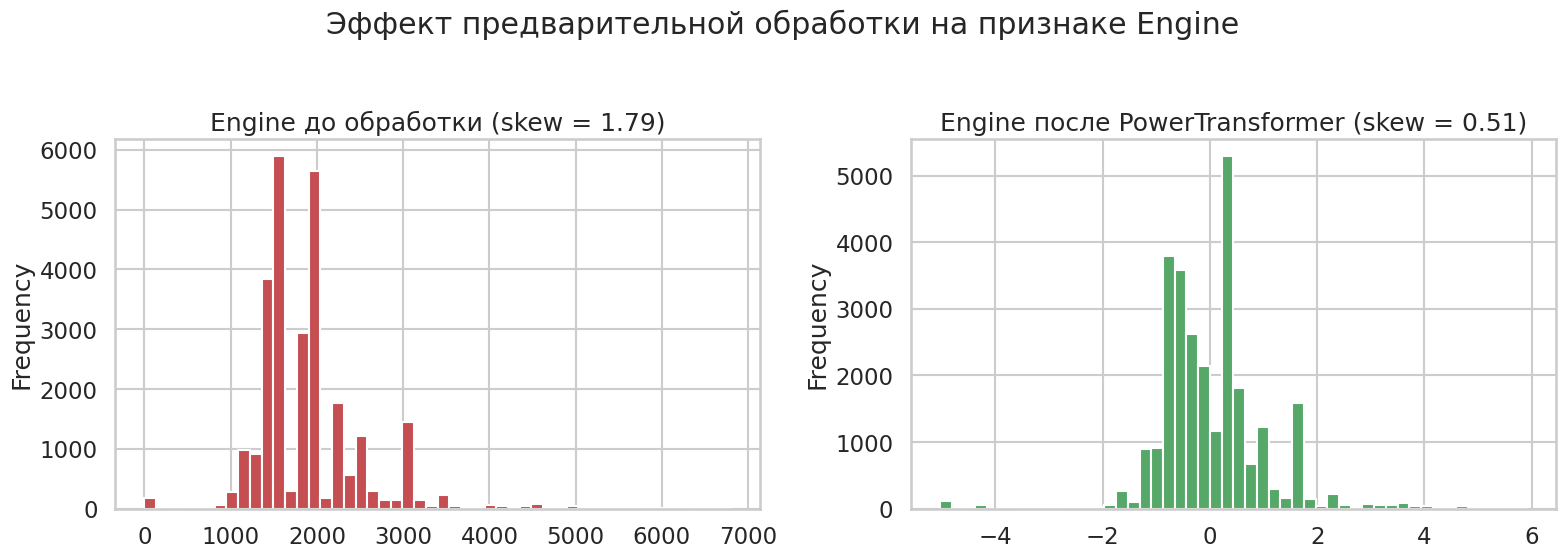

In [22]:
display(train_prep[["Age", "Distance", "Engine", "Model_freq"]].describe().loc[["mean", "std", "min", "max"]].round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
X_train["Engine"].plot.hist(bins=50, ax=axes[0], color="#C44E52", edgecolor="white")
axes[0].set_title(f"Engine до обработки (skew = {X_train['Engine'].skew():.2f})")
train_prep["Engine"].plot.hist(bins=50, ax=axes[1], color="#55A868", edgecolor="white")
axes[1].set_title(f"Engine после PowerTransformer (skew = {train_prep['Engine'].skew():.2f})")
fig.suptitle("Эффект предварительной обработки на признаке Engine", y=1.03)
plt.tight_layout(); plt.show()

**Что мы видим.** У числовых признаков среднее близко к 0, а стандартное отклонение к 1. Асимметрия объёма двигателя заметно уменьшилась (хвост справа стал короче). Столбцы One-Hot содержат 0 и 1, а редкие марки и типы кузова собраны в категорию `Other`. Остаточная асимметрия `Engine` сохраняется из-за небольшого числа очень мощных машин, для линейных моделей это приемлемо.

### 5.5 Сохранение результата

In [23]:
train_out = train_prep.assign(LogPrice=y_train)
test_out = test_prep.assign(LogPrice=y_test)
train_out.to_csv("cars_moldova_train_prepared.csv", index=False)
test_out.to_csv("cars_moldova_test_prepared.csv", index=False)
print("Сохранено:", train_out.shape, test_out.shape)

Сохранено: (27732, 51) (6934, 51)


## 6. Итоги
* **Очистка:** удалены дубликаты (~9%), исправлены единицы измерения пробега, отсечены нереалистичные значения цены, пробега, года и объёма двигателя.
* **Визуализация:** цена сильно скошена (нужен логарифм), падает с возрастом и пробегом нелинейно, выше у автоматов, гибридов, электромобилей и премиальных марок.
* **Статистика:** самый сильный числовой предиктор — возраст; пробег коррелирует с возрастом; в категориальных признаках есть редкие значения, которые ненадёжны.
* **Предобработка:** для каждой группы признаков подобран свой `Pipeline`, преобразователи обучены только на train, результат сохранён в два CSV-файла и готов для обучения регрессионной модели.